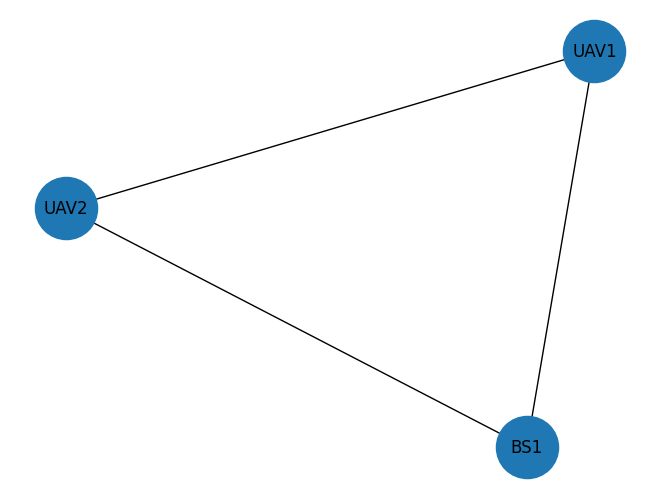

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

G.add_node("UAV1")
G.add_node("UAV2")
G.add_node("BS1")

G.add_edge("UAV1", "BS1")
G.add_edge("UAV2", "BS1")
G.add_edge("UAV1", "UAV2")

nx.draw(
    G,
    with_labels=True,
    node_size=2000,
    font_size=12
)

plt.show()

In [5]:
G.add_edge("UAV1", "BS1", weight=2.5)
G.add_edge("BS1", "UAV2", weight=1.2)
G.add_edge("UAV1", "UAV2", weight=5.0)

path = nx.shortest_path(
    G,
    "UAV1",
    "UAV2",
    weight="weight"
)

print(path)

['UAV1', 'BS1', 'UAV2']


In [3]:
# The Python graphviz package is installed.
# Its optional macOS `dot` executable is not installed, so the next cell
# automatically falls back to NetworkX + Matplotlib.


['Requirement already satisfied: graphviz in /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages (0.21)',
 '',
 '\x1b[\x1b\x1bnotice\x1b\x1b[1;39;49m]\x1b\x1b A new release of pip is available: \x1b\x1b26.0.1\x1b\x1b -> \x1b\x1b26.2.1\x1b',
 '\x1b[\x1b\x1bnotice\x1b\x1b[1;39;49m]\x1b\x1b To update, run: \x1b\x1bpip install --upgrade pip\x1b']

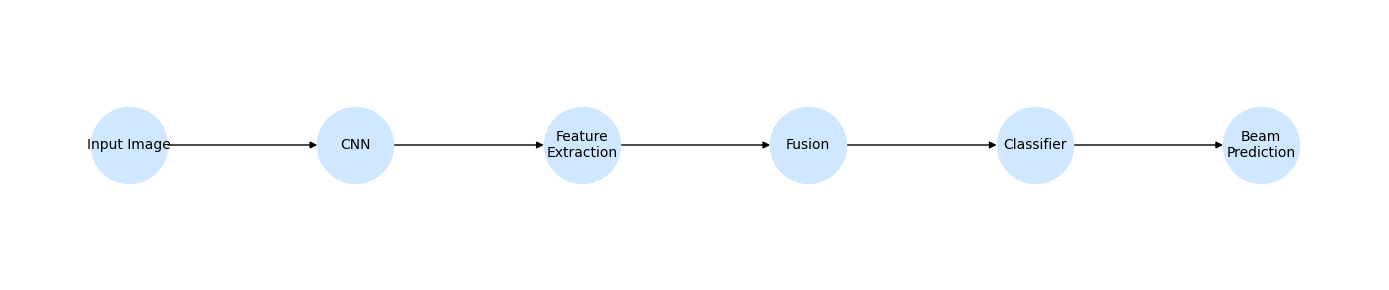

Saved pipeline diagram to: /Users/Shared/LLM/ml_pipeline.png


In [7]:
from pathlib import Path
import shutil

import matplotlib.pyplot as plt
import networkx as nx

nodes = [("A", "Input Image"), ("B", "CNN"), ("C", "Feature\nExtraction"),
         ("D", "Fusion"), ("E", "Classifier"), ("F", "Beam\nPrediction")]
edges = [("A", "B"), ("B", "C"), ("C", "D"), ("D", "E"), ("E", "F")]
output_path = Path("ml_pipeline.png")

if shutil.which("dot"):
    from graphviz import Digraph

    dot = Digraph("ML_Pipeline")
    for node_id, label in nodes:
        dot.node(node_id, label)
    for source, target in edges:
        dot.edge(source, target)
    output_path = Path(dot.render(output_path.stem, format="png", cleanup=True))
else:
    # Graphviz's system executable is unavailable; produce the same PNG with
    # packages already present in this notebook environment.
    graph = nx.DiGraph()
    graph.add_nodes_from(node_id for node_id, _ in nodes)
    graph.add_edges_from(edges)
    positions = {node_id: (index, 0) for index, (node_id, _) in enumerate(nodes)}
    labels = dict(nodes)
    figure, axis = plt.subplots(figsize=(14, 3))
    nx.draw_networkx(graph, pos=positions, labels=labels, ax=axis, arrows=True,
                     node_color="#cfe8ff", node_size=3000, font_size=10)
    axis.set_axis_off()
    figure.tight_layout()
    figure.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.show()

print(f"Saved pipeline diagram to: {output_path.resolve()}")

In [8]:
%pip install rpy2
%load_ext rpy2.ipython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [rpy2]1/3 [rpy2-robjects]

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [12]:
%%R

x <- c(1,2,3,4,5)
y <- c(2,4,6,8,10)

model <- lm(y ~ x)
summary(model)

UsageError: Cell magic `%%R` not found.
